# paper_riskDD — 01: Participant Screening & basic behavioral characterizations

#### 1. simple probit model to screen participants
All-trials probit model (model-0, both formats, no group term) to identify task-disengaged participants.
**Exclusion criterion:** < 99.9 % of the posterior slope (γ) mass above zero — insufficient evidence that
the subject uses the numerical ratio when deciding.

Final agreed exclusion list (same for both formats): `[32, 40, 45, 46, 50]`

**Indifference point** = `−intercept / γ`  (log-ratio at which P(chose risky) = 0.5).
Risk-neutral value: `log(1/0.55) ≈ 0.598`.

#### 2. basic characterizations 
- "raw data" plots...

**Outputs**
- `results/screening_per_subject_gamma.csv`
- `results/excluded_subjects.csv`
- `figures/screening_gamma_indpoint_by_group.pdf`
- `figures/screening_per_subject_gamma_kdeplots.pdf`

In [1]:
import sys, os, os.path as op
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import bambi
import arviz as az

from numrisk.behavior_risk.utils import get_data, invprobit
sys.path.insert(0, os.getcwd())
from utils_riskBehav import summarize_posterior

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2)

# ind_point = -intercept / gamma  (log-ratio where P(chose risky) = 0.5)
# risk-neutral value: log(1/0.55) ≈ 0.598
IND_NEUTRAL = -np.log(0.55)

bids_folder    = '/Users/mrenke/data/ds-dnumrisk'
trace_folder   = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
out_folder     = op.join(bids_folder, 'plots_and_ims', 'paper_riskDD')
figures_folder = op.join(out_folder, 'figures')
results_folder = op.join(out_folder, 'results')
for d in [figures_folder, results_folder]:
    os.makedirs(d, exist_ok=True)
print('Output folders ready.')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Output folders ready.


## Load behavioral data

In [2]:
df = get_data()
df['x'] = df['log(risky/safe)']

subList   = df.index.unique('subject').sort_values()
groupList = df[['group']].groupby('subject').first().astype(int)
groupList['group_label'] = groupList['group'].map({0: 'Control', 1: 'Dyscalculic'})

print(f'Subjects loaded: {len(subList)}')
print(groupList['group_label'].value_counts())

number of subjects in dataframe: 66
Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
      dtype='int64', name='subject')
Subjects loaded: 66
group_label
Control        33
Dyscalculic    33
Name: count, dtype: int64


---
## 1. Model-0: All-trials probit (no group term)

Formula: `chose_risky ~ x + x*format + (x*format|subject)`

Trace: `probit_model-0_format-both_trace.netcdf`

Model-0 has no group regressor — used purely to assess whether each subject's slope γ is
credibly different from zero.

In [3]:
trace_m0 = az.from_netcdf(op.join(trace_folder, 'probit_model-0_format-both_trace.netcdf'))

model_m0 = bambi.Model(
    'chose_risky ~ x + x*format + (x*format|subject)',
    link='probit', family='bernoulli', data=df.reset_index()
)
print('Model-0 loaded.')
print('Posterior dims:', dict(trace_m0.posterior.dims))

Model-0 loaded.
Posterior dims: {'chain': 4, 'draw': 1000, 'format_dim': 1, 'x:format_dim': 1, 'subject__factor_dim': 66, 'format__expr_dim': 1, 'x:format__expr_dim': 1}


### Extract per-subject slope γ and indifference point

Build a fake-data grid over `subject × x={0,1} × format` (no group term in model-0).

- **γ** = `invprobit(pred at x=1) − invprobit(pred at x=0)`
- **ind_point** = `−intercept / γ`  (log-ratio at which P=0.5; risk-neutral ≈ 0.598)

In [4]:
fake_data_m0 = pd.MultiIndex.from_product(
    [subList, [0, 1], df.index.unique('format')],
    names=['subject', 'x', 'format']
).to_frame().reset_index(drop=True)

pred_m0 = model_m0.predict(
    trace_m0, 'mean', fake_data_m0, inplace=False, include_group_specific=True
)['posterior']['chose_risky_mean']

pred_m0 = pred_m0.to_dataframe().unstack([0, 1])
pred_m0 = pred_m0.set_index(pd.MultiIndex.from_frame(fake_data_m0))

pred0_m0     = pred_m0.xs(0, level='x')
intercept_m0 = pd.DataFrame(invprobit(pred0_m0), index=pred0_m0.index, columns=pred0_m0.columns)
gamma_m0     = invprobit(pred_m0.xs(1, level='x')) - intercept_m0

print('γ and intercept extracted.')
print('Index levels:', gamma_m0.index.names)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


γ and intercept extracted.
Index levels: ['subject', 'format']


### Exclusion criterion: P(γ > 0) ≥ 0.999

In [5]:
ALPHA = 0.001  # require 99.9 % of posterior mass above zero

excluded_m0 = []
records = []

for sub in subList:
    tmp_sub    = gamma_m0.xs(sub, level='subject').unstack('format')
    p_positive = float((tmp_sub.values > 0).mean())
    records.append({
        'subject':     sub,
        'group':       groupList.loc[sub, 'group'],
        'group_label': groupList.loc[sub, 'group_label'],
        'p_gamma_gt0': p_positive,
        'excluded':    p_positive < (1 - ALPHA)
    })
    if p_positive < (1 - ALPHA):
        excluded_m0.append(sub)

df_screening = pd.DataFrame(records).set_index('subject')

print('=== Subjects failing exclusion criterion (model-0) ===')
print(df_screening[df_screening['excluded']].to_string())
print(f'\nExcluded list (model-0): {excluded_m0}')

=== Subjects failing exclusion criterion (model-0) ===
         group  group_label  p_gamma_gt0  excluded
subject                                           
32           1  Dyscalculic     0.964125      True
40           1  Dyscalculic     0.980125      True
45           1  Dyscalculic     0.991125      True
46           1  Dyscalculic     0.617125      True
50           1  Dyscalculic     0.861375      True

Excluded list (model-0): [32, 40, 45, 46, 50]


In [ ]:
EXCLUDED_SUBJECTS = [32, 40, 45, 46, 50]  # confirmed across model-0 and model-1; applied to both formats

df_screening['excluded_final'] = df_screening.index.isin(EXCLUDED_SUBJECTS)
df_screening.to_csv(op.join(results_folder, 'screening_per_subject_gamma.csv'))

---
## 2. Basic characterization — included subjects

"raw data" plots

In [13]:
from scipy.stats import ttest_ind

# test for each stake size of Prop_risky_choices different
format='symbolic'
stake_sizes = df['n_safe'].unique()

EXCLUDED = [32, 40, 45, 46, 50]

df_included = df.drop(index=EXCLUDED, level='subject')#.xs(format, level='format')
df_included.rename(columns={'n_safe':'Stake Size'}, inplace=True)

df_included['group_label'] = df_included['group'].map({0: 'Control', 1: 'Dyscalculic'})

format: non-symbolic
  t=-2.416, p=0.019
format: symbolic
  t=-1.508, p=0.137


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn

Text(3.599444444444453, 0.5, 'Mean RT (sec.)')

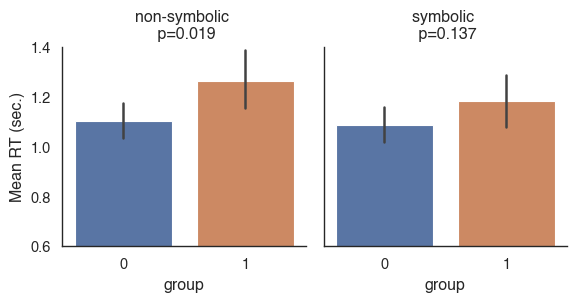

In [44]:
tmp = df_included.groupby(['group', 'subject','format'])['rt'].mean()
fig = sns.catplot(tmp.reset_index(), x='group', y='rt', hue='group', col = 'format', kind='bar', height=3, aspect=1, legend=False)
fig.axes[0,0].set_ylabel('Mean RT (sec.)')

for i, format in enumerate(['non-symbolic', 'symbolic']):
    print(f'format: {format}')
    tmp_tmp = tmp.xs(format, level='format').groupby(['group', 'subject']).mean()
    stat, pval = ttest_ind(tmp_tmp.xs(0, level='group'), tmp_tmp.xs(1, level='group'))
    print(f'  t={stat:.3f}, p={pval:.3f}')
    fig.axes[0,i].set_title(f'{format} \n p={pval:.3f}')
    fig.axes[0,i].set(ylim=(0.6, 1.4))
fig.axes[0,0].set_ylabel('Mean RT (sec.)')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn

format: non-symbolic
  t=1.396, p=0.168
format: symbolic
  t=2.053, p=0.045
non-symbolic - False: t=0.379, p=0.706
non-symbolic - True: t=0.838, p=0.405
symbolic - False: t=0.399, p=0.691
symbolic - True: t=1.467, p=0.148


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn

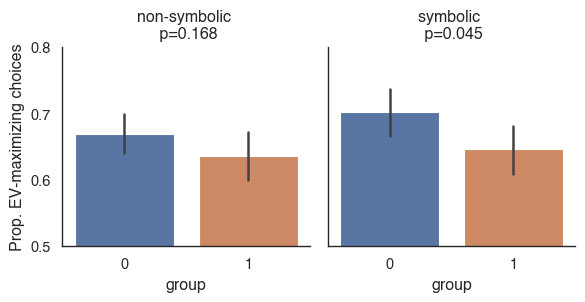

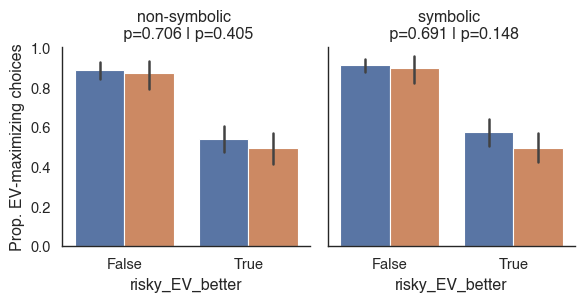

In [54]:
## Proportion of EV-maximizing choices

df_included['EV_risky'] = 0.55 * df_included['n_risky']
df_included['EV_safe'] = 1 * df_included['Stake Size']
df_included['EV_maximized'] = (df_included['EV_risky'] > df_included['EV_safe']) == df_included['chose_risky']
df_included['risky_EV_better'] = df_included['EV_risky'] > df_included['EV_safe']

tmp = df_included.groupby(['group', 'subject','format'])['EV_maximized'].mean()
fig = sns.catplot(tmp.reset_index(), x='group', y='EV_maximized', hue='group', col = 'format', kind='bar', height=3, aspect=1, legend=False)
fig.axes[0,0].set_ylabel('Prop. EV-maximizing choices')
for i, format in enumerate(['non-symbolic', 'symbolic']):
    print(f'format: {format}')
    tmp_tmp = tmp.xs(format, level='format').groupby(['group', 'subject']).mean()
    stat, pval = ttest_ind(tmp_tmp.xs(0, level='group'), tmp_tmp.xs(1, level='group'))
    print(f'  t={stat:.3f}, p={pval:.3f}')
    fig.axes[0,i].set_title(f'{format} \n p={pval:.3f}')
    fig.axes[0,i].set(ylim=(0.5, 0.8))


tmp = df_included.groupby(['group', 'subject','format','risky_EV_better'])['EV_maximized'].mean()
fig = sns.catplot(tmp.reset_index(), x='risky_EV_better', y='EV_maximized', hue='group', col = 'format', kind='bar', height=3, aspect=1, legend=False)
fig.axes[0,0].set_ylabel('Prop. EV-maximizing choices')

for i, format in enumerate(['non-symbolic', 'symbolic']):
    p_vals = []
    for j, risky_better in enumerate([False, True]):
        tmp_tmp = tmp.xs(format, level='format').xs(risky_better, level='risky_EV_better').groupby(['group', 'subject']).mean()
        stat, pval = ttest_ind(tmp_tmp.xs(0, level='group'), tmp_tmp.xs(1, level='group'))
        p_vals.append(pval)
        print(f'{format} - {risky_better}: t={stat:.3f}, p={pval:.3f}')
    fig.axes[0,i].set_title(f'{format} \n p={p_vals[0]:.3f} | p={p_vals[1]:.3f}')
    #fig.axes[0,i].set(ylim=(0.5, 0.8))

In [ ]:
from scipy.stats import ttest_ind

for ss in stake_sizes:
    print(f'stakeSize: {ss}')
    tmp = df_included.set_index('n_safe', append=True).xs(ss, level='n_safe').groupby(['group', 'subject'])['chose_risky'].mean()
    stat, pval = ttest_ind(tmp.xs(0, level='group'), tmp.xs(1, level='group'))
    print(f'  t={stat:.3f}, p={pval:.3f}')

stakeSize: 7.0
  t=1.741, p=0.087
stakeSize: 5.0
  t=1.295, p=0.201
stakeSize: 10.0
  t=1.133, p=0.262
stakeSize: 14.0
  t=1.100, p=0.276
stakeSize: 20.0
  t=0.357, p=0.723
stakeSize: 28.0
  t=-0.335, p=0.738


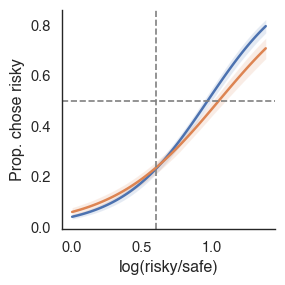

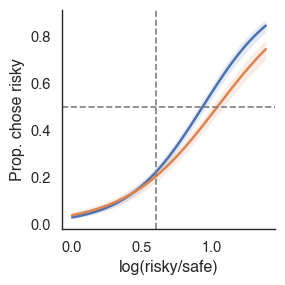

In [55]:
y_var = 'chose_risky'
x_var = 'log(risky/safe)'
hue = 'group'

for format in ['non-symbolic', 'symbolic']:
    tmp = df_included.xs(format, level='format').groupby(['group', 'subject', x_var])[y_var].mean()
    fig = sns.lmplot(tmp.reset_index(), x=x_var, y=y_var, hue=hue,logistic=True,
                        height=3, aspect=1 , scatter=False,
                    legend=False) #  col='age',
    fig.axes[0,0].set_ylabel('Prop. chose risky')
    plt.axhline(y=0.5,color='grey', ls='--')
    plt.axvline(x=np.log(1/.55),color='grey', ls='--')
    plt.savefig(op.join(figures_folder, f'raw_choseRisk_log-ratio_format-{format}.pdf'), bbox_inches='tight')



/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:1202: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a

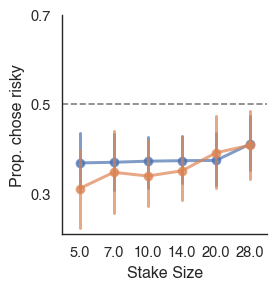

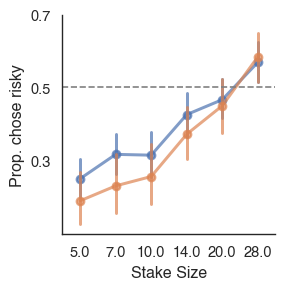

In [57]:
y_var = 'chose_risky'
x_var = 'Stake Size'
hue = 'group'

for format in ['non-symbolic', 'symbolic']:
    tmp = df_included.xs(format, level='format').groupby(['group', 'subject', x_var])[y_var].mean()
    fig = sns.catplot(tmp.reset_index(), x=x_var, y=y_var, hue=hue,kind='point',
                        height=3, aspect=1 , 
                        alpha= 0.7 ,legend=False) #  col='age',
    fig.axes[0,0].set_ylabel('Prop. chose risky')
    fig.axes[0, 0].set_yticks([0.3,0.5,0.7])

    plt.axhline(y=0.5,color='grey', ls='--')
    #plt.savefig(op.join(figures_folder, f'raw_choseRisk_stake-size_format-{format}.pdf'), bbox_inches='tight')


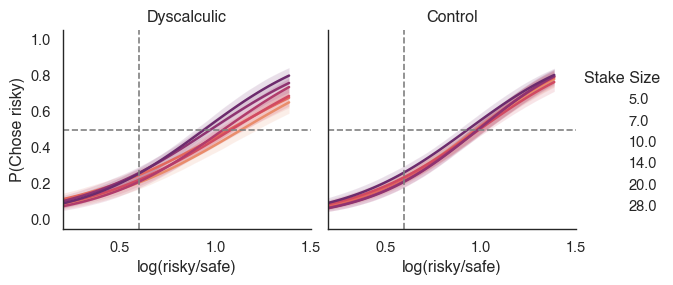

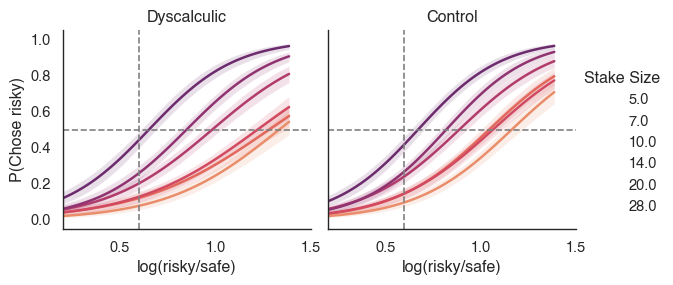

In [60]:
y_var = 'chose_risky'
x_var = 'log(risky/safe)'
hue = 'Stake Size'
col = 'group_label'

palette = sns.color_palette('flare')#"dark:#5A9_r") #"blend:#7AB,#EDA") #,  n_colors=df[hue].nunique())

for format in ['non-symbolic', 'symbolic']:
    tmp = df_included.xs(format, level='format')
    fig = sns.lmplot(tmp.reset_index(), x=x_var, y=y_var, hue= hue, col=col,ci=95,  height=3, aspect=1,
                    logistic=True,scatter_kws={'s': 0}, # show only the line and no 
                    palette=palette)

    fig.set_titles("{col_name}")
    for ax in fig.axes.flat:
        ax.axvline(x=np.log(1/0.55),color='grey', ls='--')
        ax.axhline(y=0.5,color='grey', ls='--')
        ax.set_xlim(0.2,1.5)

    fig.axes[0,0].set_ylabel('P(Chose risky)')
    plt.savefig(op.join(figures_folder, f'raw_choiceCurves_stake-size_format-{format}.pdf'), bbox_inches='tight')
